# Temperature pleasantness

How comfortable a place feels temperature-wise, per 0.5° grid cell. Uses **apparent temperature** (accounts for humidity) from NASA POWER climatology (1991–2020, `T2M` + `RH2M`), scored against a user-tunable comfort band. Ocean cells are masked via `is_land` from `grid.nc`.

The score is deliberately **preference-driven**: some people prefer cool with real seasons, others prefer hot and steady. The pipeline is therefore two-stage:

1. **Stage A (expensive, run once):** fetch monthly T + RH, compute per-month apparent temperature on the atlas grid, cache to `processed/_apparent_temp_monthly.nc`.
2. **Stage B (cheap, rerun any time):** collapse the 12 monthly layers into an annual pleasantness score using two knobs (`ideal_temp`, `tolerance`). This is what `90_scoring.ipynb` consumes.

Changing preferences after the fact does not re-hit the API or re-interpolate — just call `helpers.compute_temperature_pleasantness(ideal_temp, tolerance)`.

In [28]:
import json

import numpy as np
import pandas as pd

from common import (
    RAW_DIR,
    PROCESSED_DIR,
    TEMP_PROFILES,
    load_grid,
    plot_map,
    save_variable,
)

from common import compute_temperature_pleasantness

VARIABLE = 'temperature_pleasantness'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)
intermediate = PROCESSED_DIR / '_apparent_temp_monthly.nc'

## 1. Fetch raw data

NASA POWER's climatology *regional* endpoint returns monthly + annual means on a 0.5° lat × 0.625° lon grid. The endpoint caps request area at ~10° × 10°, so we tile the globe into 648 tiles and cache each response as JSON. Same pattern as `13_sun_hours.ipynb`, but requesting two parameters (`T2M`, `RH2M`) instead of one.

First run: ~15–25 min (sequential requests). Re-runs: instant (cached).

In [29]:
from common import download_nasa_power_dataset
download_nasa_power_dataset(variable_raw, "T2M")
download_nasa_power_dataset(variable_raw, "RH2M")

POWER tiles: 100%|██████████| 648/648 [00:00<00:00, 38327.37it/s]


1297 tiles cached in /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/raw/temperature_pleasantness


POWER tiles: 100%|██████████| 648/648 [00:00<00:00, 94365.29it/s]

1297 tiles cached in /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/raw/temperature_pleasantness


## 2. Clean & assemble monthly climatology

Each tile JSON is a GeoJSON FeatureCollection. Every feature is a grid point with `geometry.coordinates = [lon, lat]` and `properties.parameter.{T2M,RH2M}.{JAN..DEC, ANN}`. We take all 12 monthly means for both variables. NASA POWER uses `-999` as its fill value — skip those.

In [30]:
MONTHS = ['JAN', 'FEB', 'MAR', 'APR', 'MAY', 'JUN',
          'JUL', 'AUG', 'SEP', 'OCT', 'NOV', 'DEC']

records = []
for tile_path in sorted(variable_raw.glob('tile_*_T2M.json')):
    doc = json.loads(tile_path.read_text())
    for feature in doc['features']:
        lon, lat = feature['geometry']['coordinates'][:2]  # ignore elevation
        params = feature['properties']['parameter']
        t = feature['properties']['parameter']['T2M']
        for m_idx, m in enumerate(MONTHS, start=1):
            tv = t.get(m)
            if tv is None or  tv < -900:
                continue
            records.append((lat, lon, m_idx, tv, None))

for tile_path in sorted(variable_raw.glob('tile_*_RH2M.json')):
    doc = json.loads(tile_path.read_text())
    for feature in doc['features']:
        lon, lat = feature['geometry']['coordinates'][:2]  # ignore elevation
        params = feature['properties']['parameter']
        rh = feature['properties']['parameter']['RH2M']
        for m_idx, m in enumerate(MONTHS, start=1):
            rv = rh.get(m)
            if rv is None or rv < -900:
                continue
            records.append((lat, lon, m_idx, None, rv))

# aggregates the dataframe, and groups the two values together
df = (pd.DataFrame(records, columns=['lat', 'lon', 'month', 'T', 'RH'])
    .groupby(['lat', 'lon', 'month'], as_index=False)
    .agg({'T': 'first', 'RH': 'first'}))
df

,lat,lon,month,T,RH
0,-90.0,-180.000,1,-28.77,92.52
1,-90.0,-180.000,2,-40.32,94.67
2,-90.0,-180.000,3,-51.85,95.50
3,-90.0,-180.000,4,-56.14,92.28
4,-90.0,-180.000,5,-56.84,91.56
...,...,...,...,...,...
2495227,90.0,179.375,8,-1.03,94.76
2495228,90.0,179.375,9,-6.66,96.82
2495229,90.0,179.375,10,-13.24,97.04
2495230,90.0,179.375,11,-19.31,95.82


## 3. Compute apparent temperature and interpolate onto the grid

**Formula (Steadman, simplified, no wind term):**

```
e   = (RH / 100) · 6.105 · exp(17.27 · T / (237.7 + T))   # water vapour pressure, hPa
AT  = T + 0.33 · e − 4.00                                   # apparent temperature, °C
```

NASA POWER also exposes `WS10M`, but the temp/humidity terms dominate for comfort scoring and skipping wind keeps the download small and the formula legible. A future contributor can extend the formula without touching downstream steps.

After computing AT per row we pivot to an xarray `(month, lat, lon)` cube, bilinear-interp onto the 0.5° atlas grid (same method as `13_sun_hours.ipynb`), mask ocean, and cache to `processed/_apparent_temp_monthly.nc`. The underscore prefix signals this file is **not** a scoring layer — it's the frozen climate substrate.

In [31]:
t = df['T']
e = (df['RH'] / 100.0) * 6.105 * np.exp(17.27 * t / (237.7 + t))
df['AT'] = t + 0.33 * e - 4.00

at_source = (df.set_index(['month', 'lat', 'lon'])['AT']
               .to_xarray()
               .sortby(['month', 'lat', 'lon']))

grid = load_grid()
at_monthly = at_source.interp(lat=grid.lat, lon=grid.lon, method='linear')
at_monthly = at_monthly.where(grid.is_land == 1).astype('float32')
at_monthly.name = 'apparent_temp_monthly'
at_monthly.attrs['units'] = '°C (Steadman apparent temperature, T2M + RH2M, no wind term)'

at_monthly.to_netcdf(intermediate)
print(f'wrote {intermediate}')
at_monthly

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/_apparent_temp_monthly.nc


<xarray.DataArray 'apparent_temp_monthly' (month: 12, lat: 360, lon: 720)> Size: 12MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 360, 720), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:    °C (Steadman apparent temperature, T2M + RH2M, no wind term)

## 4. Sanity-check the climate signal

Two quick plots before we score anything:

- **Annual mean apparent temperature.** Should look Köppen-ish — hot near the equator, cold at the poles, deserts warmer than their latitude peers.
- **Annual range** (`max − min` across months). Should peak in continental interiors of the northern hemisphere (Siberia, central Canada) and stay low near coasts and equator.

<Axes: title={'center': 'annual mean apparent temperature (°C)'}, xlabel='longitude', ylabel='latitude'>

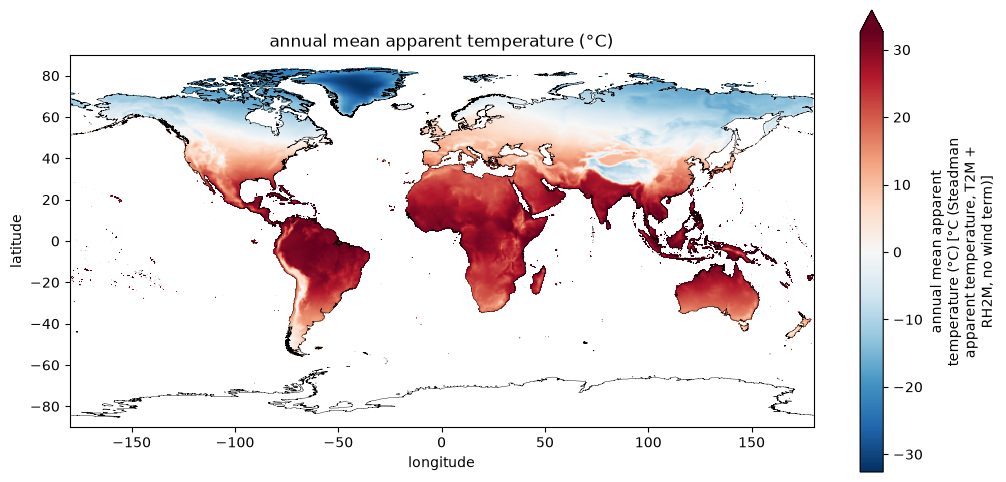

In [32]:
annual_mean = at_monthly.mean('month')
annual_mean.name = 'annual mean apparent temperature (°C)'
plot_map(annual_mean, cmap='RdBu_r', robust=True)

<Axes: title={'center': 'annual apparent-temperature range (°C)'}, xlabel='longitude', ylabel='latitude'>

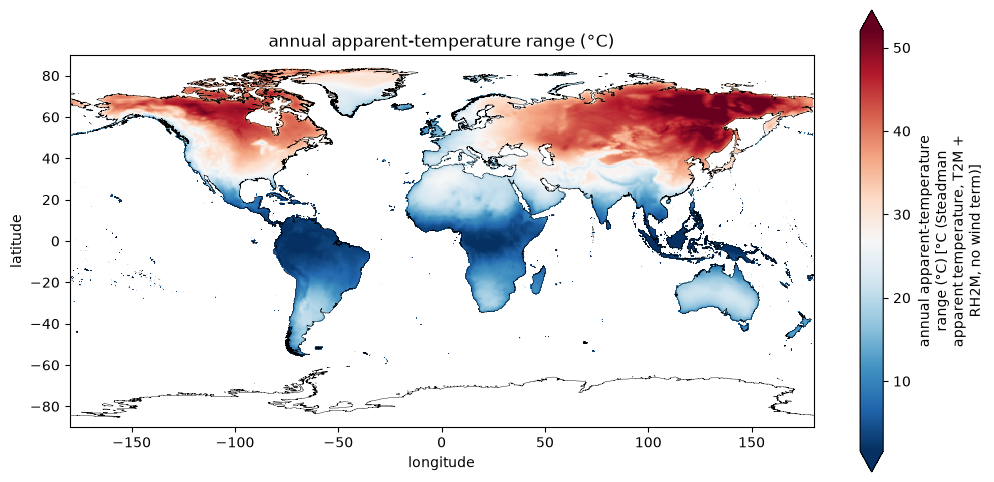

In [33]:
annual_range = at_monthly.max('month') - at_monthly.min('month')
annual_range.name = 'annual apparent-temperature range (°C)'
plot_map(annual_range, cmap='RdBu_r', robust=True)

## 5. Preference knobs → pleasantness

Per-month triangular comfort function, then annual mean, then multiplied by a range-fit factor:

```
comfort(month) = clip(1 − |AT(month) − ideal_temp| / tolerance, 0, 1)
base           = mean of comfort over 12 months
expected_range = 2 · tolerance
range_fit      = clip(1 − |actual_range − expected_range| / expected_range, 0, 1)
pleasantness   = base · range_fit
```

Range 0–1, higher = better. `tolerance` does double duty: it is the half-width of the per-month comfort band *and* implies the expected annual swing (`2·tolerance`). Cells whose actual swing matches that score high, cells that are much flatter (Nairobi, Bogotá, Kunming — mean temperature might be perfect but annual range is only ~3–5 °C) or much wider get pulled down. Because the range-fit is intrinsic, the same preset that rewards Rome cannot accidentally reward Nairobi.

**Presets (see `TEMP_PROFILES` in `common.py`):**

- *Polar (−15 °C ±25):* expected swing 50 °C — Norilsk, Iqaluit, Yellowknife, Verkhoyansk. Extreme continental subarctic where winter goes to −40 and summer touches +15.
- *Cold Winters (−5 °C ±20):* expected swing 40 °C — Anchorage, Murmansk, Nuuk, Moscow. Classic subarctic seasonality.
- *Cool Seasonal (8 °C ±15):* expected swing 30 °C — Berlin, Toronto, Sapporo, most of temperate NH.
- *Mediterranean (18 °C ±12):* expected swing 24 °C — Rome, Athens, Barcelona, LA, Cape Town, Perth.
- *Hot (25 °C ±15):* expected swing 30 °C — Cairo, desert-margin continental (Riyadh, Phoenix summers).
- *Tropical Steady (32 °C ±3):* expected swing 6 °C — Singapore, Kuala Lumpur, Jakarta, Bangkok, Manila. Apparent temperature sits at ~32 °C year-round because humidity lifts it well above the raw air temp.

In [34]:
IDEAL_TEMP = 20.0  # °C — target apparent temperature
TOLERANCE = 10.0   # °C — half-width of the comfort band

pleasantness = compute_temperature_pleasantness(
    source=intermediate,
    ideal_temp=IDEAL_TEMP,
    tolerance=TOLERANCE,
)
pleasantness.name = VARIABLE
pleasantness.attrs['ideal_temp_C'] = IDEAL_TEMP
pleasantness.attrs['tolerance_C'] = TOLERANCE
pleasantness

<xarray.DataArray 'temperature_pleasantness' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:         °C (Steadman apparent temperature, T2M + RH2M, no wind term)
    ideal_temp_C:  20.0
    tolerance_C:   10.0

## 6. Plot pleasantness (and a preference-sensitivity peek)

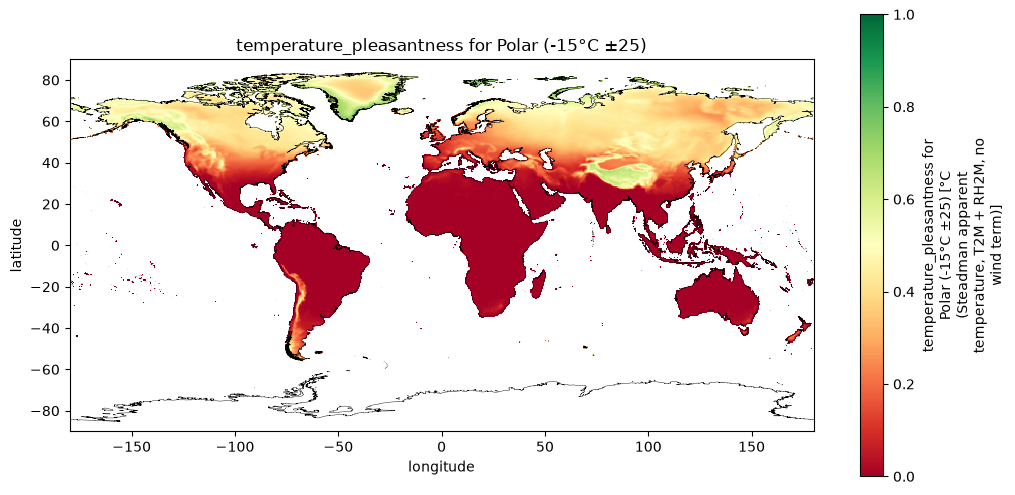

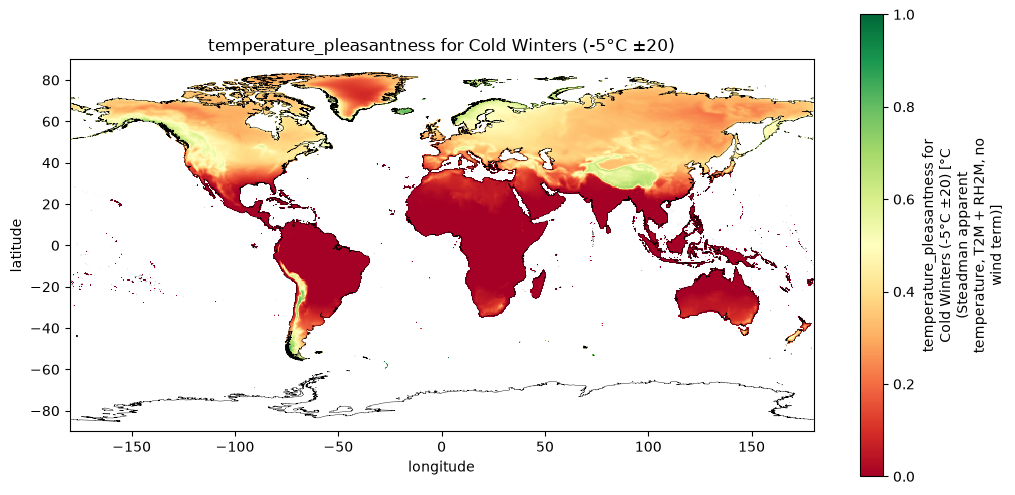

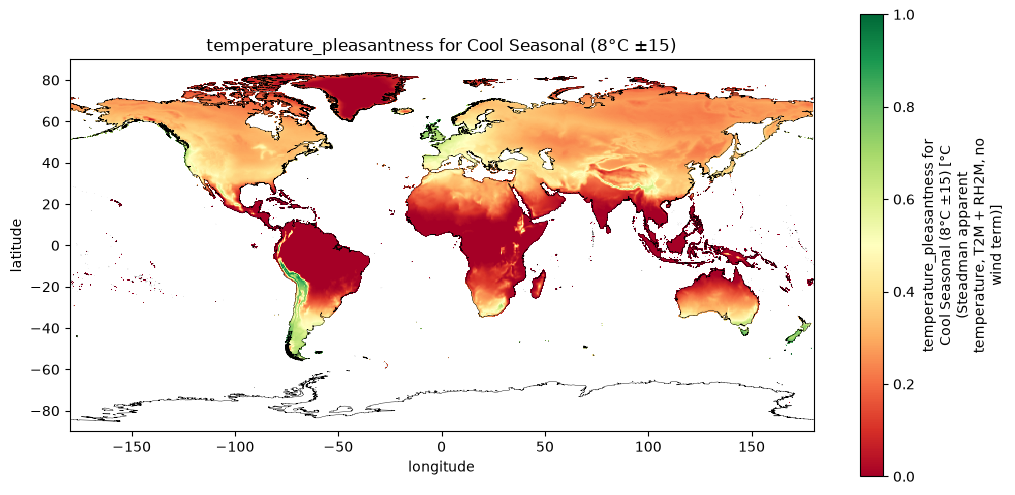

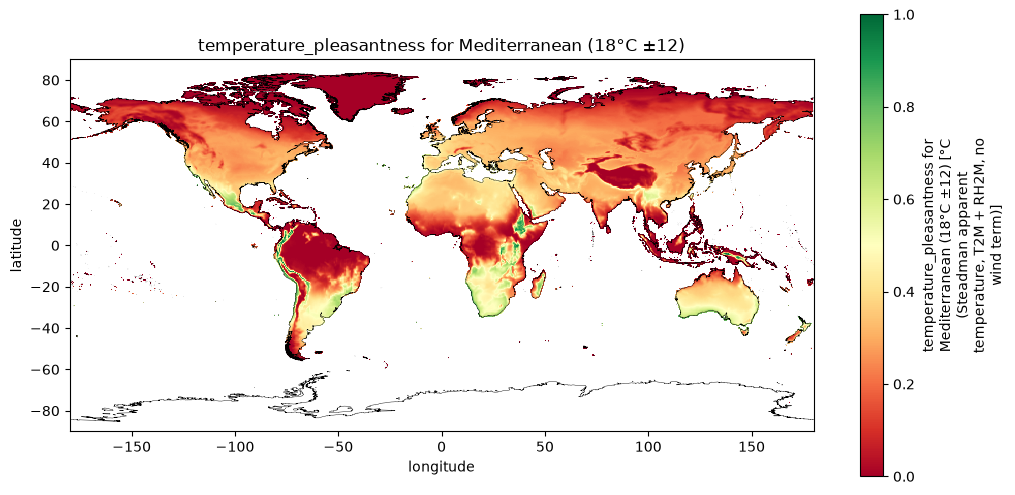

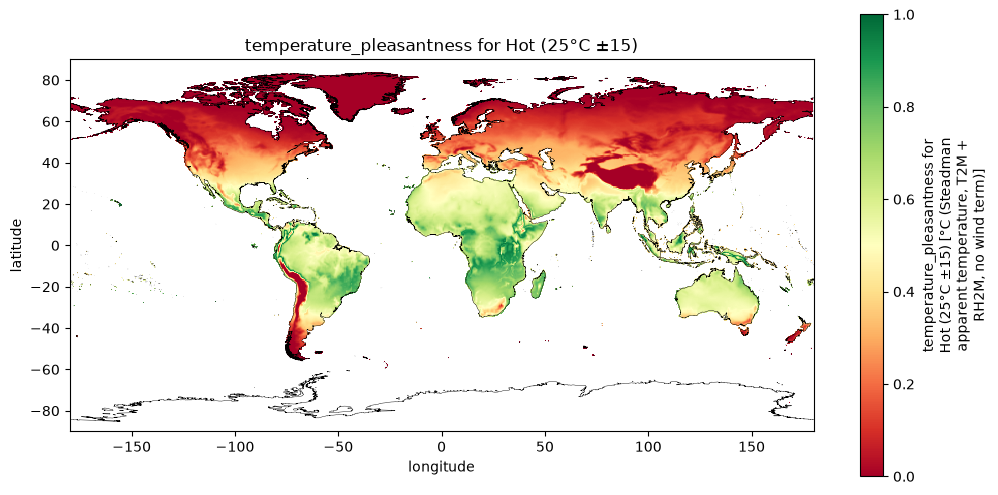

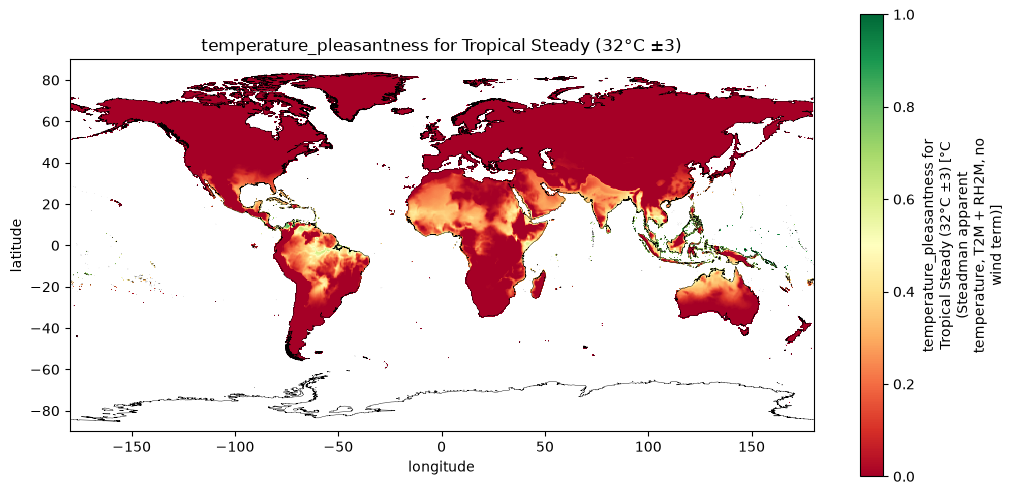

In [ ]:
TEMP_PROFILES = {
    'Polar (-15°C ±25)':          (-15.0, 25.0),
    'Cold Winters (-5°C ±20)':    ( -5.0, 20.0),
    'Cool Seasonal (8°C ±15)':    (  8.0, 15.0),
    'Mediterranean (18°C ±12)':   ( 18.0, 12.0),
    'Hot (25°C ±15)':             ( 25.0, 15.0),
    'Tropical Steady (32°C ±3)':  ( 32.0,  5.0),
}

for label, (ideal, tol) in TEMP_PROFILES.items():
    alt = compute_temperature_pleasantness(source=intermediate, ideal_temp=ideal, tolerance=tol)
    alt.name = f'temperature_pleasantness for {label}'
    plot_map(alt, cmap='RdYlGn', vmin=0, vmax=1)

## 7. Save

Writes the default-preference score to `processed/temperature_pleasantness.nc` so `90_scoring.ipynb` picks it up. Re-scoring the atlas for a different preference is a one-liner: `compute_temperature_pleasantness(...).to_netcdf(...)`.

In [36]:
out = save_variable(pleasantness, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/world-liveable-atlas/data/world-livable-atlas/processed/temperature_pleasantness.nc
